# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [3]:
# Code Here
import pandas as pd

penguins = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
penguins = penguins.dropna()

penguins.head()



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [4]:
penguins_dum = pd.get_dummies(penguins, drop_first=True)

penguins_dum.head()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,False,False,True,True
1,39.5,17.4,186.0,3800.0,False,False,False,True,False
2,40.3,18.0,195.0,3250.0,False,False,False,True,False
4,36.7,19.3,193.0,3450.0,False,False,False,True,False
5,39.3,20.6,190.0,3650.0,False,False,False,True,True


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Your best multiple linear regression model from before
* Two kNN models (for different values of K)
* A decision tree model

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

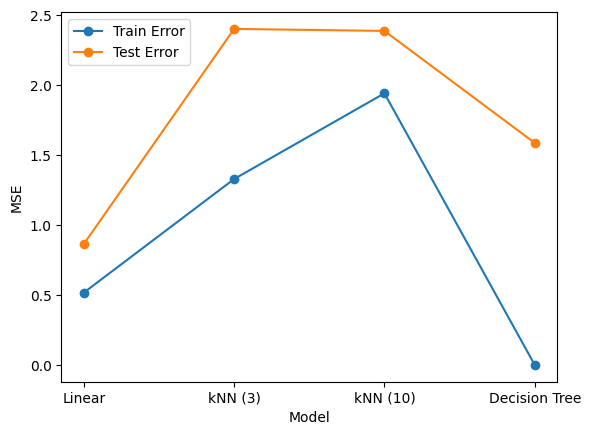

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X = penguins_dum.drop(columns=["bill_depth_mm"]).values
y = penguins_dum["bill_depth_mm"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lin = LinearRegression().fit(X_train, y_train)
knn3 = KNeighborsRegressor(n_neighbors=3).fit(X_train, y_train)
knn10 = KNeighborsRegressor(n_neighbors=10).fit(X_train, y_train)
tree = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)

models = {
    "Linear": lin,
    "kNN (3)": knn3,
    "kNN (10)": knn10,
    "Decision Tree": tree
}

train_errors = []
test_errors = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

plt.plot(list(models.keys()), train_errors, marker='o')
plt.plot(list(models.keys()), test_errors, marker='o')
plt.xlabel("Model")
plt.ylabel("MSE")
plt.legend(["Train Error", "Test Error"])
plt.show()



The decision tree is overfitting because it gets almost perfect training error but does much worse on the test set. The kNN models don’t perform very well either since both their training and test errors are pretty high. The linear model ends up being the best because it has the lowest test error, so it generalizes better than the others.